In [1]:
# https://www.analyticsvidhya.com/blog/2019/02/outlier-detection-python-pyod/

In [2]:
import pandas as pd
import numpy as np
import os
data_path = './data/' 
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.font_manager

# Import models
from pyod.models.abod import ABOD
from pyod.models.cblof import CBLOF
from pyod.models.feature_bagging import FeatureBagging
from pyod.models.hbos import HBOS
from pyod.models.iforest import IForest
from pyod.models.knn import KNN
from pyod.models.lof import LOF
# reading the big mart sales training data
df = pd.read_csv(os.path.join(data_path,'train_bigmart.csv')) 


<Axes: xlabel='Item_MRP', ylabel='Item_Outlet_Sales'>

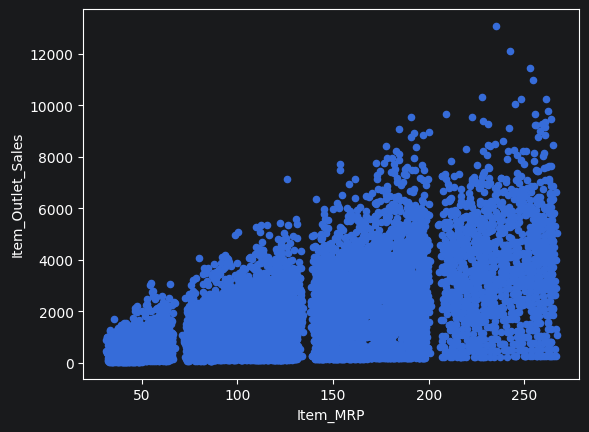

In [3]:
#Let’s plot Item MRP vs Item Outlet Sales to understand the data:

df.plot.scatter('Item_MRP','Item_Outlet_Sales')

In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
df[['Item_MRP','Item_Outlet_Sales']] = scaler.fit_transform(df[['Item_MRP','Item_Outlet_Sales']])
df[['Item_MRP','Item_Outlet_Sales']].head()


,Item_MRP,Item_Outlet_Sales
0,0.927507,0.283587
1,0.072068,0.031419
2,0.468288,0.158115
3,0.640093,0.053555
4,0.095805,0.073651


In [5]:
X1 = df['Item_MRP'].values.reshape(-1,1)
X2 = df['Item_Outlet_Sales'].values.reshape(-1,1)

X = np.concatenate((X1,X2),axis=1)

In [6]:
random_state = np.random.RandomState(42)
outliers_fraction = 0.05
# Define seven outlier detection tools to be compared
classifiers = {
        'Angle-based Outlier Detector (ABOD)': ABOD(contamination=outliers_fraction),
        'Cluster-based Local Outlier Factor (CBLOF)':CBLOF(contamination=outliers_fraction,check_estimator=False, random_state=random_state),
        'Feature Bagging':FeatureBagging(LOF(n_neighbors=35),contamination=outliers_fraction,check_estimator=False,random_state=random_state),
        'Histogram-base Outlier Detection (HBOS)': HBOS(contamination=outliers_fraction),
        'Isolation Forest': IForest(contamination=outliers_fraction,random_state=random_state),
        'K Nearest Neighbors (KNN)': KNN(contamination=outliers_fraction),
        'Average KNN': KNN(method='mean',contamination=outliers_fraction)
}

OUTLIERS : 447  INLIERS : 8076  Angle-based Outlier Detector (ABOD)


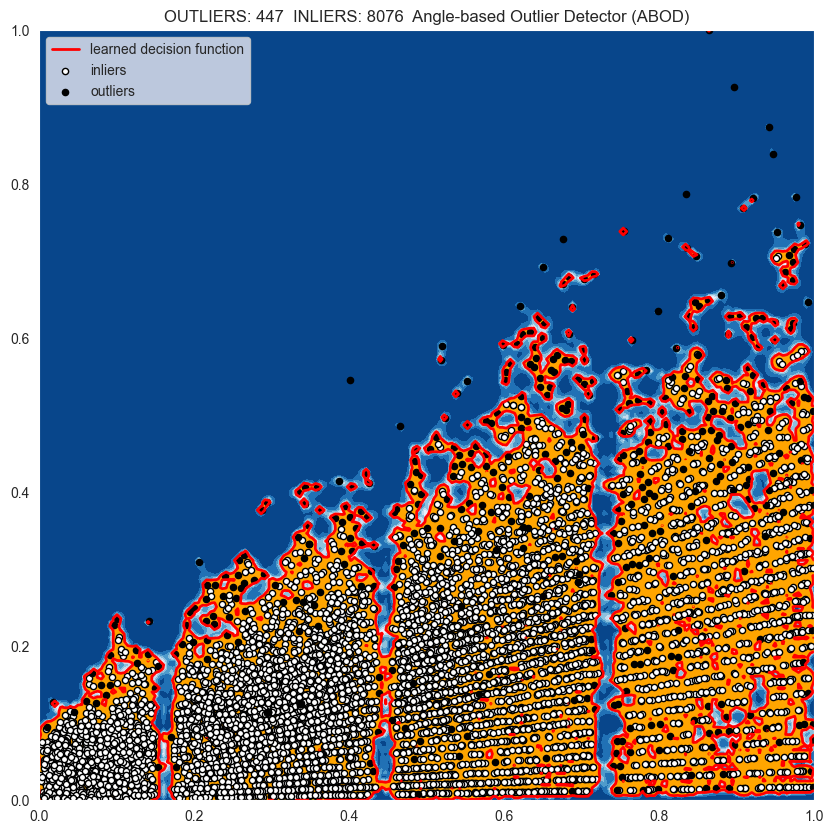

OUTLIERS : 427  INLIERS : 8096  Cluster-based Local Outlier Factor (CBLOF)


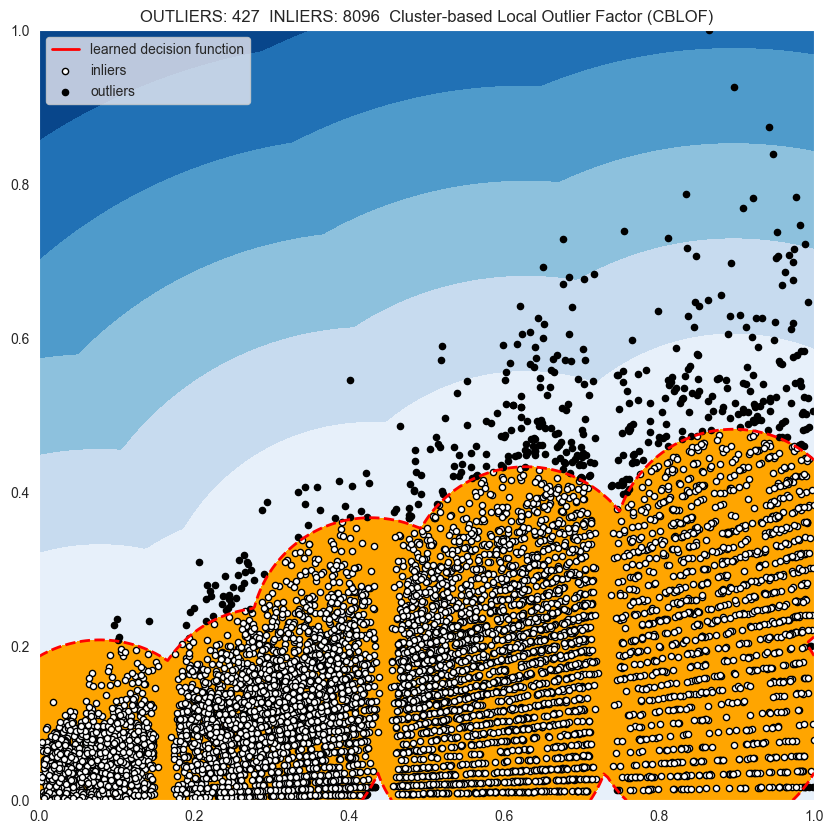

OUTLIERS : 358  INLIERS : 8165  Feature Bagging


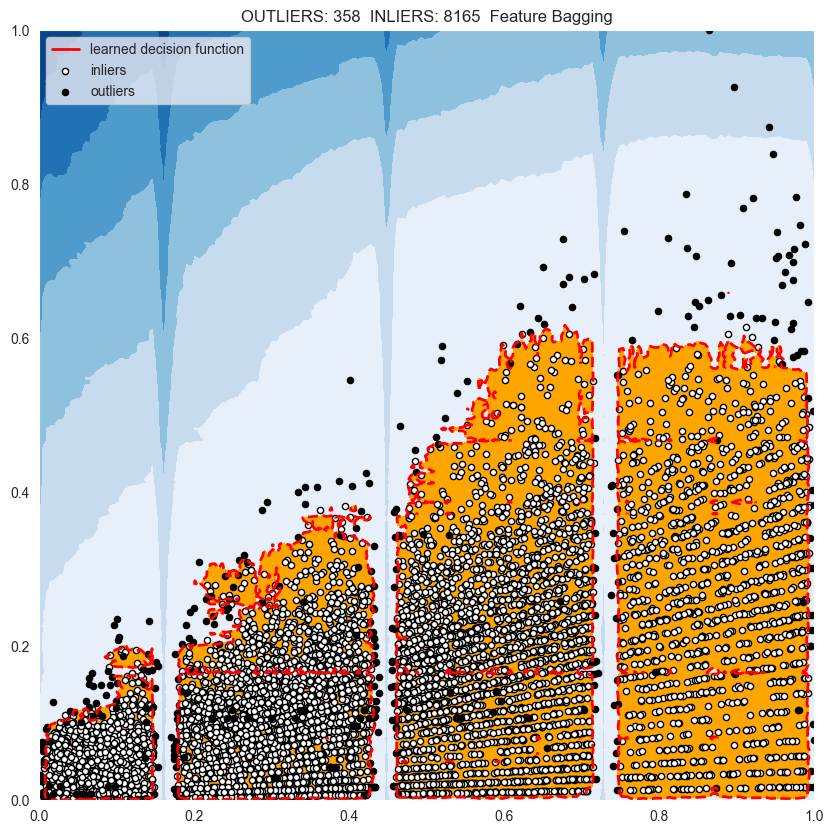

OUTLIERS : 418  INLIERS : 8105  Histogram-base Outlier Detection (HBOS)


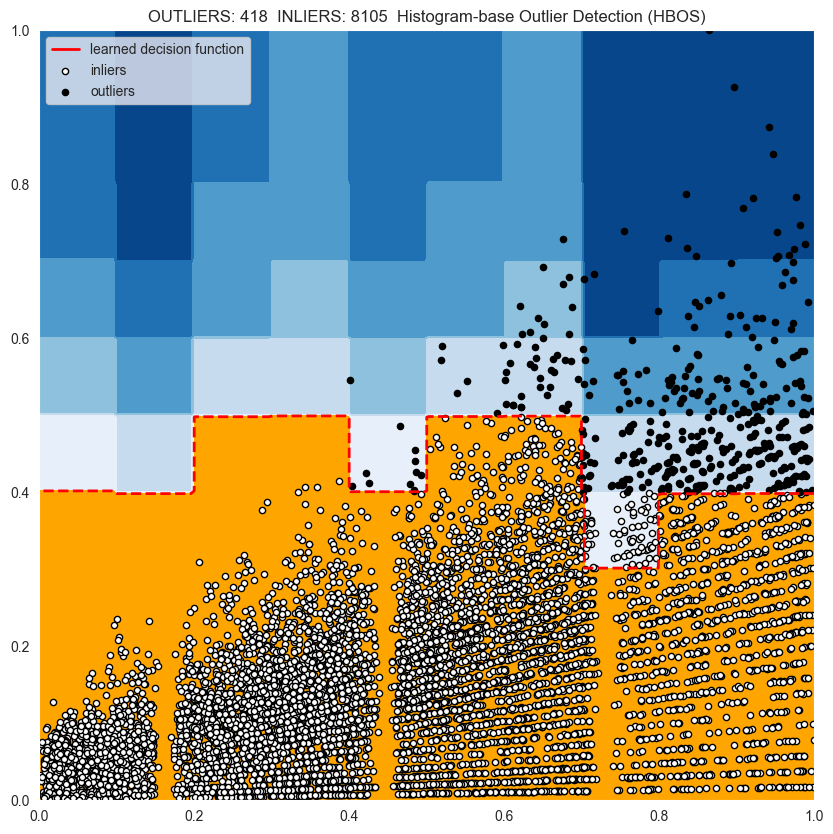

OUTLIERS : 427  INLIERS : 8096  Isolation Forest


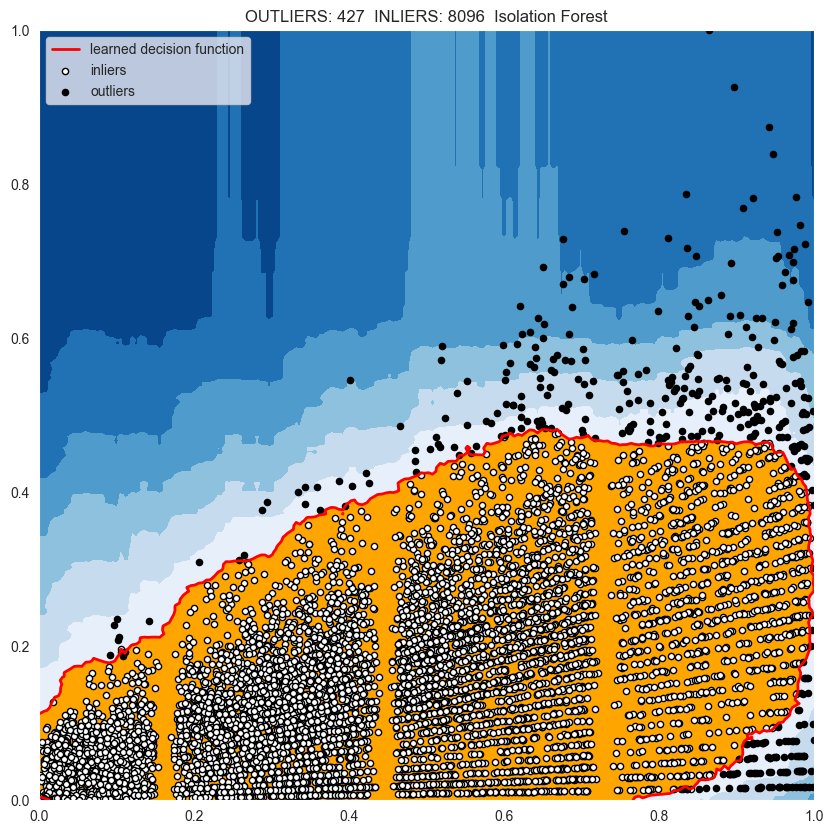

OUTLIERS : 311  INLIERS : 8212  K Nearest Neighbors (KNN)


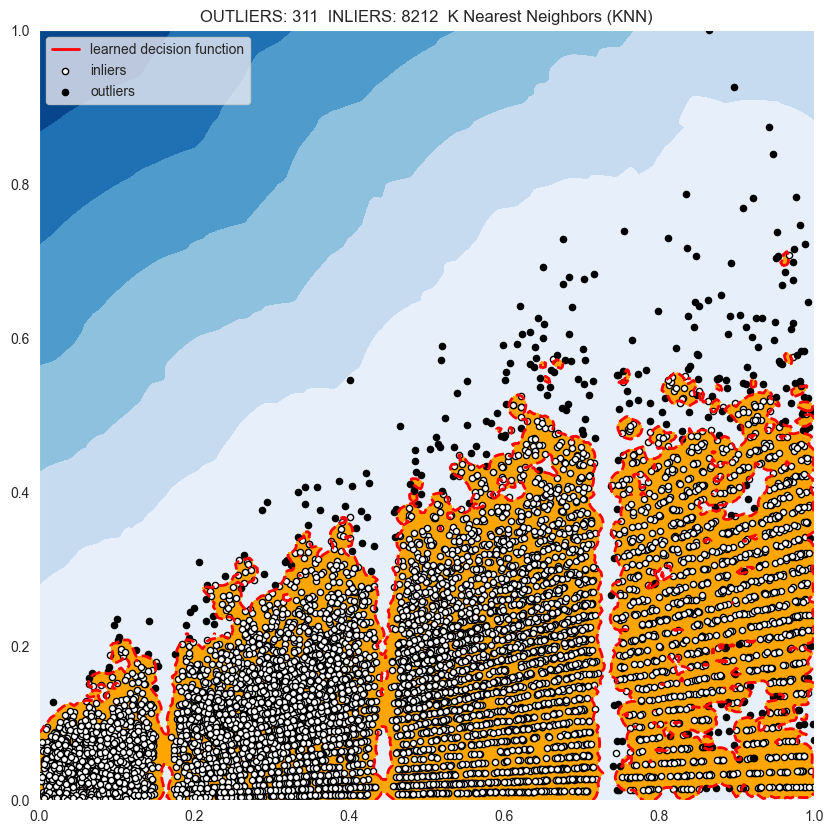

OUTLIERS : 176  INLIERS : 8347  Average KNN


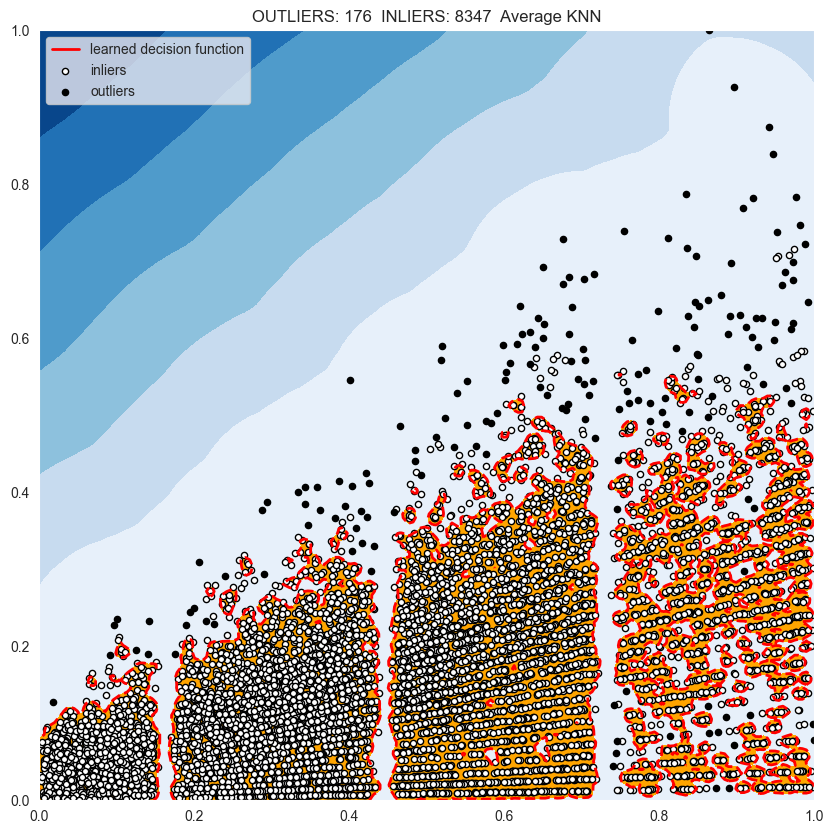

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D  # Required for the legend fix
from scipy import stats

# 1. Setup the meshgrid for the background decision boundaries
# This uses the min/max of your scaled features (X)
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min(), X[:,0].max(), 200),
    np.linspace(X[:,1].min(), X[:,1].max(), 200)
)

# 2. Loop through each classifier
for i, (clf_name, clf) in enumerate(classifiers.items()):
    # Fit the model to the data
    clf.fit(X)

    # Predict raw anomaly score (multiplied by -1 for contour plotting logic)
    scores_pred = clf.decision_function(X) * -1

    # Prediction of a datapoint category: 1 for Outlier, 0 for Inlier (PyOD Standard)
    y_pred = clf.predict(X)

    # Calculate counts based on predictions
    n_outliers = np.sum(y_pred == 1)
    n_inliers = np.sum(y_pred == 0)

    plt.figure(figsize=(10, 10))

    # Create a copy of the dataframe for plotting
    dfx = df.copy()
    dfx['outlier'] = y_pred # 1 = Outlier, 0 = Inlier

    # IX1, IX2: Features for Inliers (where outlier == 0)
    IX1 = np.array(dfx['Item_MRP'][dfx['outlier'] == 0]).reshape(-1,1)
    IX2 = np.array(dfx['Item_Outlet_Sales'][dfx['outlier'] == 0]).reshape(-1,1)

    # OX1, OX2: Features for Outliers (where outlier == 1)
    OX1 = np.array(dfx['Item_MRP'][dfx['outlier'] == 1]).reshape(-1,1)
    OX2 = np.array(dfx['Item_Outlet_Sales'][dfx['outlier'] == 1]).reshape(-1,1)

    # Print the counts to the console
    print(f'OUTLIERS : {n_outliers}  INLIERS : {n_inliers}  {clf_name}')

    # Calculate the threshold value for the decision boundary
    threshold = stats.scoreatpercentile(scores_pred, 100 * outliers_fraction)

    # Calculate the raw anomaly score for every point in the meshgrid for the background
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]) * -1
    Z = Z.reshape(xx.shape)

    # Fill blue colormap for the inlier region
    plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), threshold, 7), cmap=plt.cm.Blues_r)

    # Draw the red contour line at the threshold
    # Note: We save this to 'a' but use a Proxy Artist for the legend
    a = plt.contour(xx, yy, Z, levels=[threshold], linewidths=2, colors='red')

    # Fill orange for the outlier region
    plt.contourf(xx, yy, Z, levels=[threshold, Z.max()], colors='orange')

    # Plot the actual data points
    b = plt.scatter(IX1, IX2, c='white', s=20, edgecolor='k') # Inliers
    c = plt.scatter(OX1, OX2, c='black', s=20, edgecolor='k') # Outliers

    plt.axis('tight')

    # --- LEGEND FIX ---
    # Create a proxy artist (Line2D) to represent the red contour line in the legend
    line_handle = Line2D([0], [0], color='red', linewidth=2)

    plt.legend(
        [line_handle, b, c],
        ['learned decision function', 'inliers', 'outliers'],
        loc=2
    )
    # ------------------

    plt.xlim((0, 1))
    plt.ylim((0, 1))

    # Update the title to show the dynamic counts
    plt.title(f"OUTLIERS: {n_outliers}  INLIERS: {n_inliers}  {clf_name}")
    plt.show()

In [11]:
from sklearn.metrics import silhouette_score

# Dictionary to store the quality scores of each model
model_performance = {}

for clf_name, clf in classifiers.items():
    # ... (your existing fitting and prediction code) ...

    # Calculate Silhouette Score (Higher is better: -1 to 1)
    # This measures how far the 'outlier' points are from the 'inlier' cluster
    try:
        score = silhouette_score(X, y_pred)
        model_performance[clf_name] = score
    except:
        model_performance[clf_name] = -1 # Fallback if only 1 class is predicted

# --- AUTO-SELECTION LOGIC ---
best_model_name = max(model_performance, key=model_performance.get)

print("\n" + "="*30)
print("FINAL RECOMMENDATION")
print("="*30)
print(f"The Best Model is: {best_model_name}")
print(f"Separation Score: {model_performance[best_model_name]:.4f}")
print("-" * 30)

if "Isolation Forest" in best_model_name:
    print("REASON: This model created the most distinct separation between normal \n"
          "sales patterns and anomalies without being skewed by local density.")
elif "KNN" in best_model_name:
    print("REASON: This model identified outliers that are significantly \n"
          "distant from all other data clusters.")
else:
    print("REASON: This model successfully identified global anomalies based \n"
          "on the geometric distribution (angles/density) of the features.")


FINAL RECOMMENDATION
The Best Model is: Angle-based Outlier Detector (ABOD)
Separation Score: 0.2902
------------------------------
REASON: This model successfully identified global anomalies based 
on the geometric distribution (angles/density) of the features.
